# Galaxy Bias Example

This example loads one subvolume from `iz155`, computes the galaxy bias relative to halos, and plots the result.

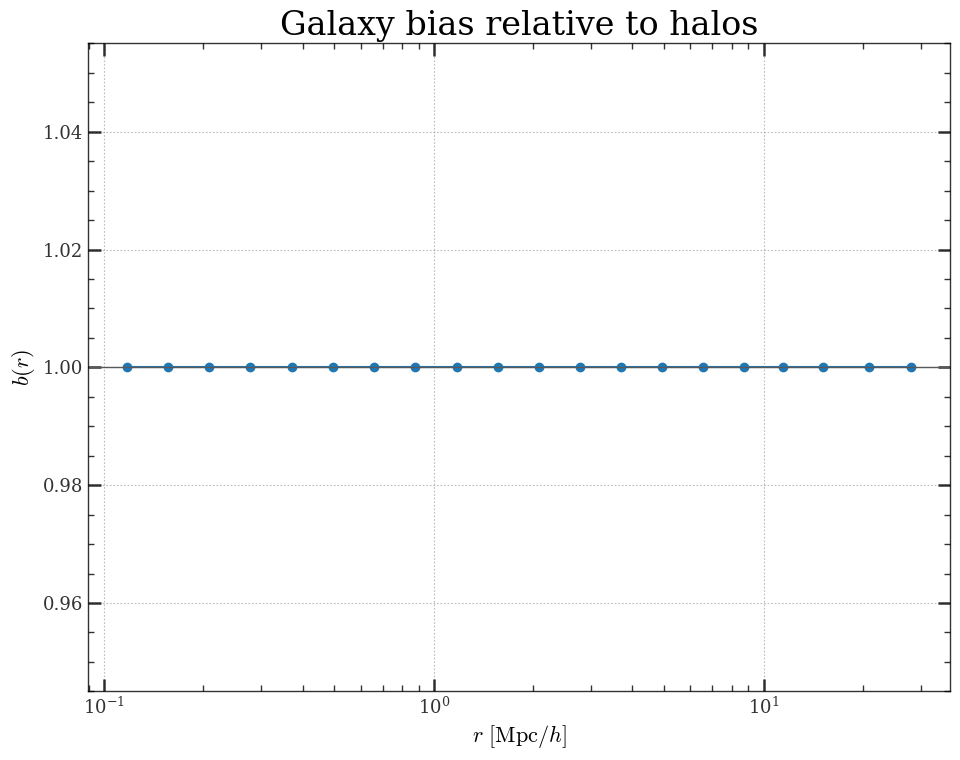

In [3]:
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'galform_analysis').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root containing galform_analysis/')


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.setconfig()

from galform_analysis.analysis.correlation.correlation import correlation_given_redshift_and_subvolume, halo_correlation_given_redshift_and_subvolume
from galform_analysis.analysis.correlation.galaxy_bias import compute_galaxy_bias
from galform_analysis.config import get_base_dir

iz_path = Path(get_base_dir()) / 'iz155'
xi_gal = correlation_given_redshift_and_subvolume(str(iz_path), 0)
xi_halo = halo_correlation_given_redshift_and_subvolume(str(iz_path), 0)
bias = compute_galaxy_bias(xi_gal, xi_halo)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(bias['r'], bias['bias'], 'o-', lw=1.5)
ax.axhline(1.0, color='0.35', lw=1)
ax.set_xscale('log')
ax.set_xlabel(r'$r\ [\mathrm{Mpc}/h]$')
ax.set_ylabel(r'$b(r)$')
ax.set_title('Galaxy bias relative to halos')
fig.tight_layout()
plt.show()